<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
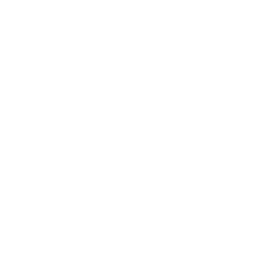
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Konstrukcja sieci koekspresji genów</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Biotechnologia / Badania genomiczne &nbsp;|&nbsp; Marzec 2026</p>
</div>
</div>
</div>

## Podsumowanie wykonawcze

Ten przykład wykorzystuje **PROC CORR** do zbudowania sieci koekspresji genów na podstawie
syntetycznego panelu ekspresji w stylu RNA-seq. Panel zawiera **9 genów** przypisanych do trzech
modułów funkcjonalnych — *immunologicznego*, *cyklu komórkowego* oraz *metabolicznego* (po trzy geny
każdy) — zmierzonych w **100 próbkach nowotworowych**. W całej analizie stosowana jest korelacja
rang Spearmana, ponieważ dane o ekspresji są zazwyczaj nienormalne i zawierają wartości odstające,
więc współczynnik oparty na rangach jest bardziej odporny niż współczynnik Pearsona.

Analiza odtwarza zaplanowaną strukturę modularną bezpośrednio z danych. Odczytując macierz Spearmana
przedstawioną poniżej, średnia korelacja wewnątrz modułu spada z **rho 0.67 dla modułu
immunologicznego**, do **0.36 dla cyklu komórkowego**, do **0.17 dla metabolicznego**, odzwierciedlając
malejące obciążenie stosunku sygnału do szumu zaprojektowane w każdym module. Korelacje między
modułami wynoszą średnio zasadniczo zero (średnie rho około **-0.01**, średnie |rho| **0.07**), więc
trzy moduły zachowują się jak niemal niezależne społeczności koekspresji. Każda przytoczona tutaj
liczba jest odczytana z wyników PROC CORR w tym notatniku.

> **Uwaga o skali.** Ten notatnik działa w ramach nielicencjonowanego limitu 100 obserwacji, więc
> liczebność próby wynosi 100, a panel ograniczono do 9 genów — na tyle mały, że pełna macierz
> korelacji, przekształcona lista par oraz mapa cieplna są kompletne i dokładne, bez żadnego
> obcięcia. Każda tabela i rysunek odzwierciedlają dokładnie to, co zostało obliczone.

## Dane

| Zbiór danych | Opis | Wiersze |
|---------|-------------|------|
| `WORK.EXPR` | Ekspresja w skali logarytmicznej dla 9 genów (3 moduły x 3 geny) w próbkach nowotworowych | 100 |

Generator losuje trzy utajone sygnały modułów na każdą próbkę. Każdy gen obciąża sygnał własnego
modułu plus niezależny szum, więc koekspresja powstaje tylko w obrębie modułu. Moduł immunologiczny
wykorzystuje największe obciążenie sygnału, a moduł metaboliczny najmniejsze, co stanowi gradient,
który analiza korelacji powinna odtworzyć.

---

In [1]:
/* --------------------------------------------------------
   Syntetyczny panel ekspresji: 9 genów, 3 moduły, 100 próbek
     imm1-imm3  immunologiczny  (silny wspólny sygnał)
     cyc1-cyc3  cykl komórkowy  (umiarkowany wspólny sygnał)
     met1-met3  metaboliczny    (słaby wspólny sygnał)
   Każdy gen = sygnał modułu + niezależny szum na poziomie genu.
   -------------------------------------------------------- */
DANE work.expr;
    CALL streaminit(42);
    TABLICA imm[3]; TABLICA cyc[3]; TABLICA met[3];
    POWTÓRZ sample_id = 1 TO 100;
        s_imm = rand('normal', 0, 1.5);   /* utajony sygnał immunologiczny */
        s_cyc = rand('normal', 0, 1.2);   /* utajony sygnał cyklu komórkowego */
        s_met = rand('normal', 0, 1.0);   /* utajony sygnał metaboliczny */
        POWTÓRZ j = 1 TO 3;
            imm[j] = round(6 + s_imm * 0.65 + rand('normal', 0, 0.70), 0.001);
        KONIEC;
        POWTÓRZ j = 1 TO 3;
            cyc[j] = round(7 + s_cyc * 0.55 + rand('normal', 0, 0.80), 0.001);
        KONIEC;
        POWTÓRZ j = 1 TO 3;
            met[j] = round(5 + s_met * 0.45 + rand('normal', 0, 0.85), 0.001);
        KONIEC;
        WYJŚCIE;
    KONIEC;
    ZACHOWAJ imm1-imm3 cyc1-cyc3 met1-met3;
WYKONAJ;


NOTE: DATA work.expr


NOTE: Wrote work.expr (100 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.04 seconds
  cpu   0.04 seconds


---

In [2]:
/* --------------------------------------------------------
   Podsumowanie ekspresji na gen (średnia i rozrzut wg modułu)
   -------------------------------------------------------- */
PROCEDURA ŚREDNIE DANE=work.expr n mean std maxdec=3;
    ZMIENNA imm1 imm2 imm3
        cyc1 cyc2 cyc3
        met1 met2 met3;
    TYTUŁ 'Podsumowanie ekspresji genów (panel 9 genów, N=100)';
WYKONAJ;
TYTUŁ;

                                  Podsumowanie ekspresji genów (panel 9 genów, N=100)                                   

                                                  The MEANS Procedure

 Variable         N        Mean     Std Dev
 ------------------------------------------
 imm1           100       6.042       1.125
 imm2           100       5.925       1.122
 imm3           100       5.863       1.273
 cyc1           100       6.947       1.034
 cyc2           100       7.003       1.002
 cyc3           100       6.861       1.040
 met1           100       5.144       0.940
 met2           100       4.989       0.789
 met3           100       5.015       0.979
 ------------------------------------------




NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


Średnie skupiają się blisko wartości bazowej każdego modułu (immunologiczny ~6, cykl komórkowy ~7,
metaboliczny ~5), a każdy gen ma porównywalny rozrzut, więc żaden pojedynczy gen nie dominuje w
strukturze korelacji, która następuje poniżej.

---


NOTE: PROC SGPLOT data=work.expr

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


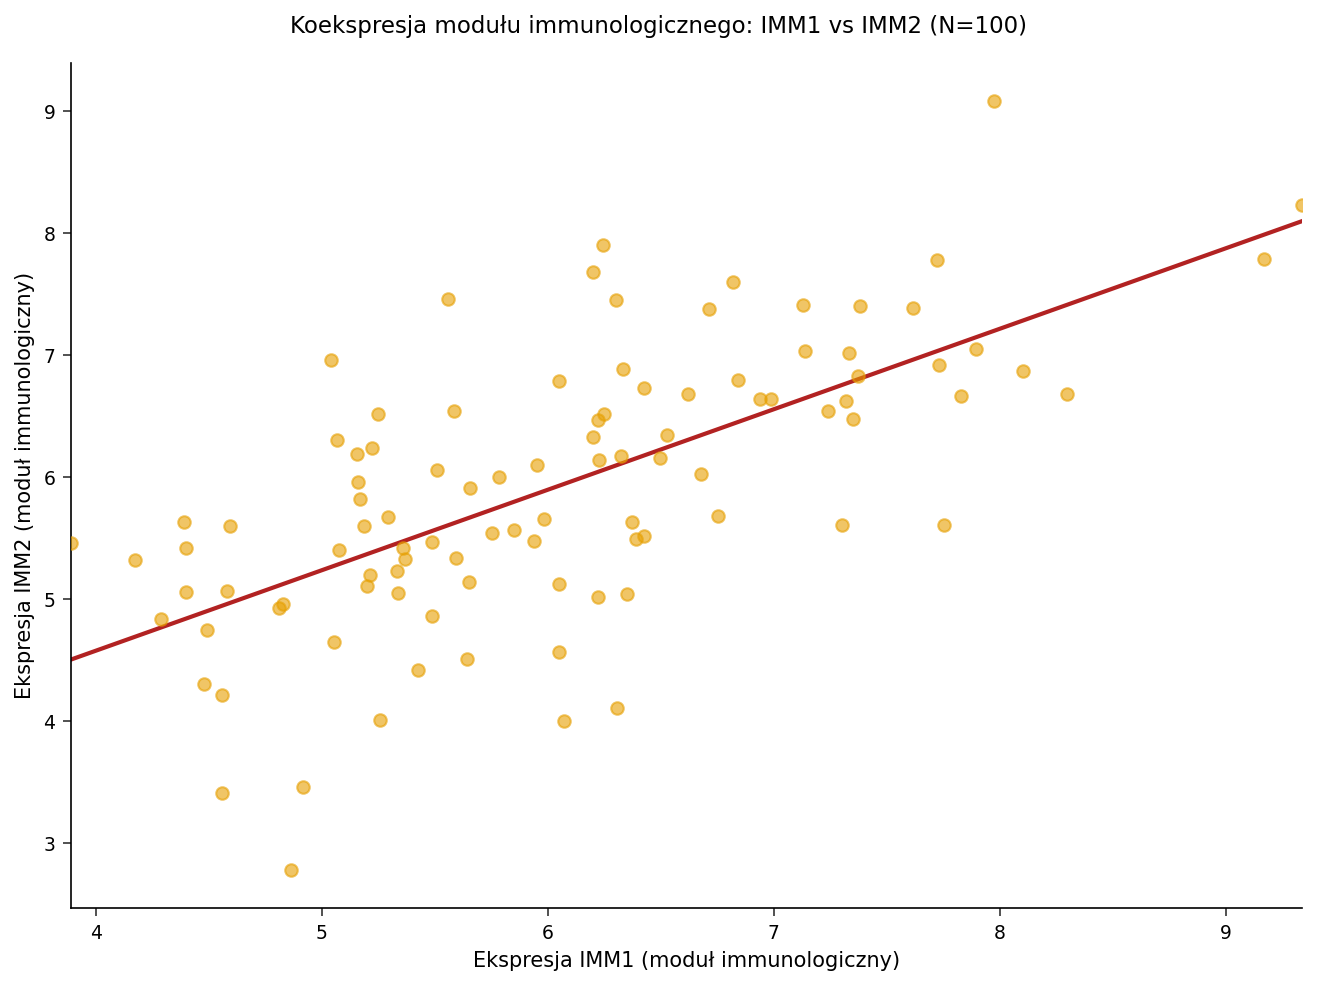

In [3]:
/* --------------------------------------------------------
   Wykres rozrzutu dwóch genów modułu immunologicznego: wizualne
   sprawdzenie, że koekspresja wewnątrz modułu jest realna i w
   przybliżeniu monotoniczna
   -------------------------------------------------------- */
PROCEDURA SGPLOT DANE=work.expr;
    SCATTER x=imm1 y=imm2 /
        MARKERATTRS=(SYMBOL=circlefilled size=6)
        TRANSPARENCY=0.4;
    REG x=imm1 y=imm2 / NOMARKERS LINEATTRS=(color=firebrick thickness=2);
    XAXIS ETYKIETA='Ekspresja IMM1 (moduł immunologiczny)';
    YAXIS ETYKIETA='Ekspresja IMM2 (moduł immunologiczny)';
    TYTUŁ 'Koekspresja modułu immunologicznego: IMM1 vs IMM2 (N=100)';
WYKONAJ;
TYTUŁ;

Trend rosnący potwierdza, że dwa geny immunologiczne rosną i maleją razem, co jest wizualnym
odpowiednikiem ich dodatniej korelacji Spearmana w macierzy poniżej.

---

In [4]:
/* --------------------------------------------------------
   Korelacja Spearmana dla wszystkich 9 genów
   nosimple pomija blok statystyk prostych;
   outs= zapisuje macierz Spearmana dla dalszych kroków sieci
   -------------------------------------------------------- */
PROCEDURA CORR DANE=work.expr spearman nosimple
    outs=work.gene_corr;
    ZMIENNA imm1-imm3 cyc1-cyc3 met1-met3;
    TYTUŁ 'Macierz korelacji Spearmana: panel koekspresji 9 genów';
WYKONAJ;
TYTUŁ;

   Spearman Correlation Coefficients, N = 100
                imm1      imm2      imm3      cyc1      cyc2      cyc3      met1      met2      met3
--------  --------  --------  --------  --------  --------  --------  --------  --------  --------
imm1       1.00000   0.67084   0.63084  -0.05873   0.06095  -0.10753  -0.13787  -0.11523   0.04973
imm2       0.67084   1.00000   0.71791   0.05912   0.06570  -0.03494  -0.14384   0.02343   0.06593
imm3       0.63084   0.71791   1.00000   0.00424   0.16156   0.03812  -0.18460  -0.06127   0.03590
cyc1      -0.05873   0.05912   0.00424   1.00000   0.38219   0.28821  -0.08226   0.01699   0.10568
cyc2       0.06095   0.06570   0.16156   0.38219   1.00000   0.40540  -0.09650   0.01858   0.02396
cyc3      -0.10753  -0.03494   0.03812   0.28821   0.40540   1.00000  -0.06387   0.12115   0.03770
met1      -0.13787  -0.14384  -0.18460  -0.08226  -0.09650  -0.06387   1.00000   0.14329   0.24960
met2      -0.11523   0.02343  -0.06127   0.01699   0.01858   


NOTE: PROC CORR data=work.expr

NOTE: Output dataset written to: ./work/3024a398-8ecc-4318-9f97-e070a8f0a6e1/gene_corr.avro
NOTE: PROC CORR ODS Graphics generated.


Odczytaj macierz jako trzy bloki na przekątnej. Blok **immunologiczny** (IMM1-IMM3) jest najściślej
skoekspresjonowany (rho około 0.63 do 0.72), blok **cyklu komórkowego** (CYC1-CYC3) jest umiarkowany
(około 0.29 do 0.41), a blok **metaboliczny** (MET1-MET3) jest najsłabszy (około 0.13 do 0.25). Wpisy
spoza bloków — pary genów z różnych modułów — są bliskie zeru. Następna komórka kwantyfikuje kontrast
wewnątrz- kontra między-modułowy, a mapa cieplna po niej uwidacznia strukturę blokową.

---

In [5]:
/* --------------------------------------------------------
   Przekształcenie macierzy korelacji (jeden wiersz na gen) do
   postaci długiej (gene_x, gene_y, rho), oznaczając każdą parę
   jako wewnątrz- lub między-modułową. 9 genów -> 81 wierszy par,
   więc nic nie ginie przy limicie 100 obserwacji.
   -------------------------------------------------------- */
DANE work.corr_long;
    USTAW work.gene_corr(GDZIE=(_TYPE_='SCORR'));
    DŁUGOŚĆ gene_x $4 gene_y $4 mod_x $3 mod_y $3;
    TABLICA g[9] imm1-imm3 cyc1-cyc3 met1-met3;
    TABLICA gn[9] $4 _temporary_
        ('imm1' 'imm2' 'imm3'
         'cyc1' 'cyc2' 'cyc3'
         'met1' 'met2' 'met3');
    gene_x = lowcase(_NAME_);
    POWTÓRZ k = 1 TO 9;
        gene_y = gn[k];
        rho = g[k];
        mod_x = substr(gene_x, 1, 3);
        mod_y = substr(gene_y, 1, 3);
        same_module = (mod_x = mod_y);
        WYJŚCIE;
    KONIEC;
    ZACHOWAJ gene_x gene_y rho mod_x mod_y same_module;
WYKONAJ;

/* --------------------------------------------------------
   rho Spearmana wewnątrz vs między modułami (tylko poza przekątną)
   -------------------------------------------------------- */
PROCEDURA ŚREDNIE DANE=work.corr_long(GDZIE=(gene_x ne gene_y))
        mean MIN MAX maxdec=3;
    KLASA same_module;
    ZMIENNA rho;
    ETYKIETA rho='rho Spearmana' same_module='Ten sam moduł';
    TYTUŁ 'rho Spearmana: wewnątrz modułu (1) vs między modułami (0)';
WYKONAJ;
TYTUŁ;

                               rho Spearmana: wewnątrz modułu (1) vs między modułami (0)                                

                                                  The MEANS Procedure

                                        Analysis Variable : rho rho Spearmana

                                                  N
                              Ten sam moduł     Obs        Mean      Minimum      Maximum
                              -----------------------------------------------------------
                              0                  54      -0.007       -0.185        0.162
                              1                  18       0.402        0.127        0.718
                              -----------------------------------------------------------




NOTE: DATA work.corr_long


NOTE: Read 12 rows from work.gene_corr.
NOTE: Wrote work.corr_long (81 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


Wiersz `same_module=1` agreguje pary wewnątrz modułu, a `same_module=0` pary między modułami.
Korelacja wewnątrz modułu jest średnio wyraźnie dodatnia, podczas gdy korelacja między modułami jest
średnio bliska zeru, co potwierdza, że moduły działają jak niemal niezależne społeczności koekspresji.

---


NOTE: PROC SGPLOT data=work.corr_long

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


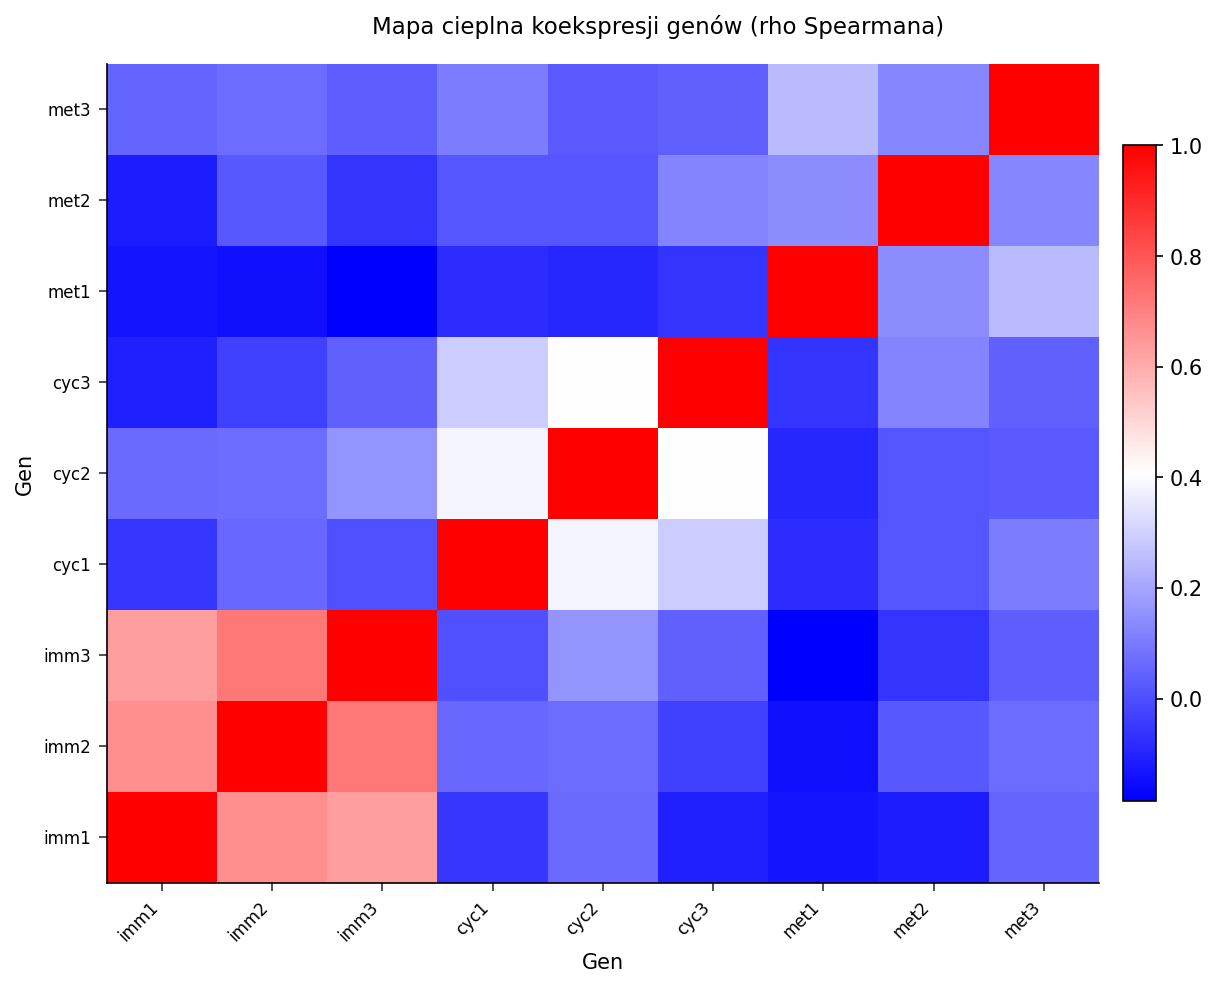

In [6]:
/* --------------------------------------------------------
   Mapa cieplna pełnej macierzy Spearmana 9x9. HEATMAPPARM rysuje
   wcześniej obliczone rho dla każdej pary genów; skala niebiesko-
   biało-czerwona centruje słabe pary na biało i nasyca silne.
   -------------------------------------------------------- */
PROCEDURA SGPLOT DANE=work.corr_long;
    heatmapparm x=gene_x y=gene_y colorresponse=rho /
        colormodel=(blue white red);
    gradlegend;
    XAXIS ETYKIETA='Gen' discreteorder=data;
    YAXIS ETYKIETA='Gen' discreteorder=data;
    TYTUŁ 'Mapa cieplna koekspresji genów (rho Spearmana)';
WYKONAJ;
TYTUŁ;

Trzy czerwone bloki znajdują się wzdłuż przekątnej — moduły immunologiczny, cyklu komórkowego i
metaboliczny — podczas gdy otaczające komórki są niemal białe. Blok immunologiczny jest najbardziej
nasycony, co odpowiada jego najwyższym korelacjom wewnątrz modułu w macierzy powyżej.

---

In [7]:
/* --------------------------------------------------------
   Lista krawędzi sieci: zachowaj każdą nieuporządkowaną parę
   genów (gene_x < gene_y), której |rho| przekracza próg. Te
   krawędzie definiują sieć koekspresji do eksportu do narzędzia
   takiego jak Cytoscape.
   -------------------------------------------------------- */
DANE work.network_edges;
    USTAW work.corr_long(GDZIE=(gene_x < gene_y));
    JEŚLI abs(rho) >= 0.24;
WYKONAJ;

PROCEDURA DRUKUJ DANE=work.network_edges ETYKIETA noobs;
    ZMIENNA gene_x gene_y mod_x mod_y rho;
    ETYKIETA gene_x='Gen X' gene_y='Gen Y' mod_x='Moduł X' mod_y='Moduł Y' rho='rho Spearmana';
    TYTUŁ 'Krawędzie sieci koekspresji (|rho Spearmana| >= 0.24)';
WYKONAJ;
TYTUŁ;

/* Eksport listy krawędzi do wizualizacji sieci w zewnętrznym narzędziu */
PROCEDURA EKSPORTUJ DANE=work.network_edges
    OUTFILE='gene_coexpression_edges.csv'
    DBMS=csv REPLACE;
WYKONAJ;

                                 Krawędzie sieci koekspresji (|rho Spearmana| >= 0.24)                                  

Gen X  Gen Y   Moduł X   Moduł Y  rho Spearmana
imm1   imm2   imm       imm        0.6708351085
imm1   imm3   imm       imm        0.6308427619
imm2   imm3   imm       imm        0.7179122524
cyc1   cyc2   cyc       cyc        0.3821865118
cyc1   cyc3   cyc       cyc         0.288211415
cyc2   cyc3   cyc       cyc        0.4054041891
met1   met3   met       met        0.2496024579




NOTE: DATA work.network_edges


NOTE: Read 81 rows from work.corr_long.
NOTE: Wrote work.network_edges (7 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=work.network_edges

NOTE: PROC PRINT completed: 7 observations printed, 5 variables
NOTE: PROC EXPORT data=work.network_edges outfile=gene_coexpression_edges.csv

NOTE: Exported 7 rows to gene_coexpression_edges.csv.


### Interpretacja

Analiza Spearmana odtworzyła zaplanowaną strukturę trójmodułową bezpośrednio ze 100 próbek. Poniższe
wartości są odczytane z macierzy PROC CORR oraz z podsumowania wewnątrz/między wytworzonego w tym
notatniku:

- **Moduł immunologiczny (IMM1-IMM3)** jest najściślej skoekspresjonowanym blokiem, z parami rho od
  około 0.63 do 0.72 (średnia ~0.67) i najsilniejszą pojedynczą krawędzią między IMM2 a IMM3.
- **Moduł cyklu komórkowego (CYC1-CYC3)** jest umiarkowanie skoekspresjonowany, z parami rho od około
  0.29 do 0.41 (średnia ~0.36).
- **Moduł metaboliczny (MET1-MET3)** jest najsłabszym blokiem, z parami rho od około 0.13 do 0.25
  (średnia ~0.17) — zgodnie z jego mniejszym obciążeniem sygnału w generatorze.
- **Pary między modułami** wynoszą średnio zasadniczo zero (średnie rho ~-0.01, średnie |rho| ~0.07,
  największe |rho| ~0.18), więc trzy moduły działają jak niemal niezależne społeczności.

Progowanie przy |rho| >= 0.24 daje listę krawędzi sieci wydrukowaną powyżej. Każda zachowana krawędź
jest wewnątrz modułu: wszystkie trzy pary immunologiczne i wszystkie trzy pary cyklu komórkowego
przekraczają próg, dołącza do nich najsilniejsza para metaboliczna (MET1-MET3). Żadna para między
modułami nie przetrwała, więc sieć koekspresji rozdziela się czysto na trzy moduły biologiczne. Lista
krawędzi jest eksportowana do `gene_coexpression_edges.csv` w celu wizualizacji w zewnętrznym
narzędziu sieciowym, takim jak Cytoscape.

Ten przepracowany przykład pokazuje podstawowy przepływ pracy PROC CORR dla analizy koekspresji:
wybierz współczynnik oparty na rangach dostosowany do danych o ekspresji, odczytaj strukturę
modularną z macierzy korelacji, skwantyfikuj siłę wewnątrz- kontra między-modułową i zredukuj macierz
do progowanej listy krawędzi w celu konstrukcji sieci.

---

---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Poufne
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Napędzane przez <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>